# Data Exploration

This notebook explores the Germany day-ahead price distribution.

### Contents
1. Load & clean the data
2. Train / validation split
3. Price distribution analysis (overall and within the overnight charging window)
4. Deriving the price bins (`Quantizer`)
5. The naive policy


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from price_loader import PriceCSVLoader


## 1. Load & clean the data

The raw file contains hourly day-ahead prices (EUR/MWh) for Germany from 2015
to a partial 2026. We:
- keep only `Datetime (Local)` and `Price`,
- re-index to a strictly hourly grid (a few hours are duplicated/missing) and interpolate
  those few gaps,
- inspect for remaining missing values.


In [2]:
raw = pd.read_csv('Germany.csv')
raw['dt'] = pd.to_datetime(raw['Datetime (Local)'])
df = raw[['dt', 'Price (EUR/MWhe)']].rename(columns={'Price (EUR/MWhe)': 'price'})
df = df.sort_values('dt').drop_duplicates(subset='dt').set_index('dt')

full_idx = pd.date_range(df.index.min(), df.index.max(), freq='h')
df = df.reindex(full_idx)
df['price'] = df['price'].interpolate(limit=3)   # fixes the handful of DST gaps
df.index.name = 'dt'

print(f"Range: {df.index.min()}  ->  {df.index.max()}")
print(f"Rows: {len(df)},  missing prices after cleaning: {df['price'].isna().sum()}")
df.head()


Range: 2015-01-01 01:00:00  ->  2026-04-21 23:00:00
Rows: 99095,  missing prices after cleaning: 0


,price
dt,
2015-01-01 01:00:00,22.34
2015-01-01 02:00:00,22.34
2015-01-01 03:00:00,22.34
2015-01-01 04:00:00,22.34
2015-01-01 05:00:00,22.34


In [3]:
df['year'] = df.index.year
yearly = df.groupby('year')['price'].agg(['mean', 'std', 'min', 'max'])
yearly


,mean,std,min,max
year,,,,
2015,31.729892,12.455309,-79.94,99.77
2016,28.979425,12.483009,-130.09,104.96
2017,34.201136,17.615195,-83.06,163.52
2018,43.463443,14.839237,-76.01,121.63
2019,37.787272,14.626876,-69.07,113.33
2020,30.408406,16.991144,-77.11,158.80
2021,97.548157,73.821569,-67.00,689.91
2022,236.497288,141.163569,-17.06,867.85
2023,95.109432,45.768963,-316.40,363.69


The years 2021–2022 were part of the European energy crisis, with very high and unstable electricity prices. After this period, prices became somewhat lower, but they are still more variable than in the years before 2021, with frequent negative prices caused by periods of high renewable energy production. For this reason, we use the most recent complete years for training and validation. This means that the agent learns from more recent electricity price patterns rather than from the entire 11-year history.

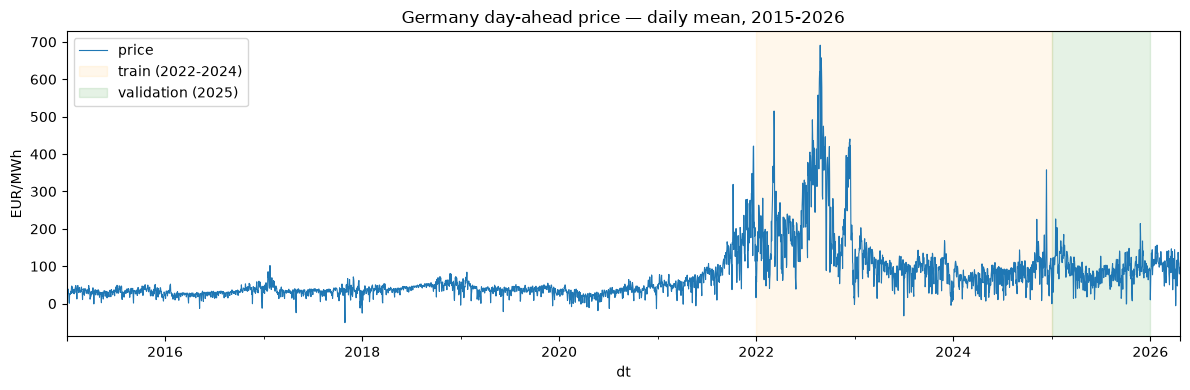

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
df['price'].resample('D').mean().plot(ax=ax, lw=0.8)
ax.set_title('Germany day-ahead price — daily mean, 2015-2026')
ax.set_ylabel('EUR/MWh')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-01-01'), color='orange', alpha=0.08, label='train (2022-2024)')
ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2026-01-01'), color='green', alpha=0.10, label='validation (2025)')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Train / validation split

3 years for training, 2 year for validation. Since this is a time series, the
split must be **chronological** (validation strictly after training), not
random. 2026 is only partially available (through April), so we use the last
three *complete* years for training and the following complete year for
validation:

- **Train:** 2021-01-01 → 2023-12-31 (3 full years)
- **Validation:** 2024-01-01 → 2025-12-31 (2 full year)

2015-2020 and the partial 2026 are left unused for this analysis.



In [8]:
train = df[(df.index.year >= 2021) & (df.index.year <= 2023)].copy()
val   = df[(df.index.year >= 2024) & (df.index.year <= 2025)].copy()

print(f"Train: {train.index.min()} -> {train.index.max()}  ({len(train)} hours)")
print(f"Val:   {val.index.min()} -> {val.index.max()}  ({len(val)} hours)")


Train: 2021-01-01 00:00:00 -> 2023-12-31 23:00:00  (26280 hours)
Val:   2024-01-01 00:00:00 -> 2025-12-31 23:00:00  (17544 hours)


## 3. Price distribution analysis


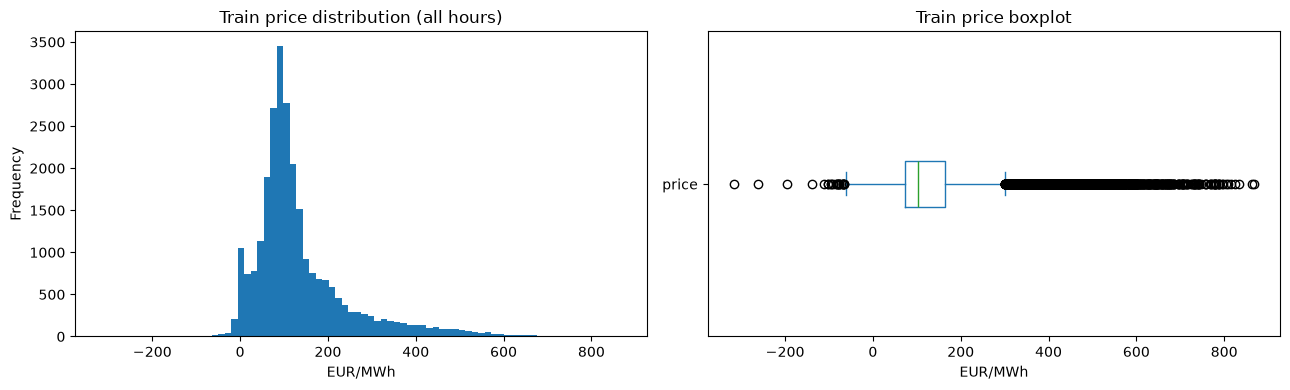

count    26304.000000
mean       136.414691
std        114.931301
min       -316.400000
25%         72.460000
50%        103.000000
75%        163.675000
max        867.850000
Name: price, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train['price'].plot(kind='hist', bins=80, ax=axes[0])
axes[0].set_title('Train price distribution (all hours)')
axes[0].set_xlabel('EUR/MWh')

train['price'].plot(kind='box', ax=axes[1], vert=False)
axes[1].set_title('Train price boxplot')
axes[1].set_xlabel('EUR/MWh')
plt.tight_layout()
plt.show()

train['price'].describe()

The EV charging problem only cares about a specific window each day: **arrival
between 17:00-20:00, departure at 07:00 the next morning**. Let's look at how
price typically evolves across the day

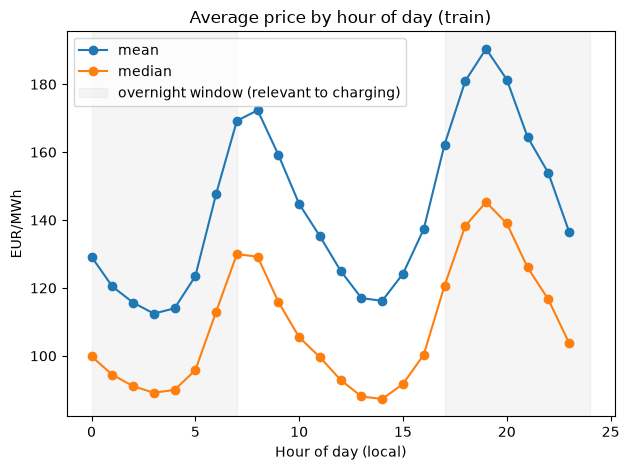

In [9]:
hourly_profile = train.groupby(train.index.hour)['price'].agg(['mean', 'median', 'std'])
ax = hourly_profile[['mean', 'median']].plot(marker='o')
ax.axvspan(17, 23.99, color='grey', alpha=0.08)
ax.axvspan(0, 7, color='grey', alpha=0.08, label='overnight window (relevant to charging)')
ax.set_xlabel('Hour of day (local)')
ax.set_ylabel('EUR/MWh')
ax.set_title('Average price by hour of day (train)')
ax.legend()
plt.tight_layout()
plt.show()


There's a clear evening peak (right when EVs typically arrive, 17:00-20:00),
a dip overnight, and a morning peak after the 07:00 deadline. This intraday
shape is *why* a price-aware policy should beat one that ignores price
entirely.


## 4. The naive policy

This baseline is the simplest charging strategy: as soon as the EV
arrives, it charges at full power until the desired state of charge is reached,
without considering the current energy price. It is intentionally price-blind,
so it defines the reference performance level that any price-aware strategy
must beat.

## 5. Deriving the price bins

Even though the naive baseline itself ignores price, discretized price bins
will be needed for any smarter policy built on top of this data later (a
hand-coded rule, or a tabular RL agent's state space). We derive them here,
from the training distribution only,:


In [11]:
overnight_mask_train = (train.index.hour >= 17) | (train.index.hour < 7)
overnight_prices_train = train.loc[overnight_mask_train, 'price']

print("Overnight-window (17:00-07:00) price stats — TRAIN:")
print(overnight_prices_train.describe())

Overnight-window (17:00-07:00) price stats — TRAIN:
count    15330.000000
mean       145.195468
std        115.683340
min        -40.140000
25%         73.430000
50%        108.260000
75%        181.167500
max        867.850000
Name: price, dtype: float64


In [12]:
LOW_HIGH_EDGES = overnight_prices_train.quantile([1/3, 2/3]).values

print(f"Price bin edges (tertiles, train overnight prices): {LOW_HIGH_EDGES.round(2)}")
print(f"  -> Low:    price <= {LOW_HIGH_EDGES[0]:.2f}")
print(f"  -> Medium: {LOW_HIGH_EDGES[0]:.2f} < price <= {LOW_HIGH_EDGES[1]:.2f}")
print(f"  -> High:   price > {LOW_HIGH_EDGES[1]:.2f}")


Price bin edges (tertiles, train overnight prices): [ 86.11 146.48]
  -> Low:    price <= 86.11
  -> Medium: 86.11 < price <= 146.48
  -> High:   price > 146.48


**Why percentile (equal-count) rather than equal-width bins?** We have seen that price is heavily
right-skewed (a long tail of expensive spike hours). Equal-width bins over that range would put almost every hour in a
single "low" bucket and leave the others nearly empty. Equal-count bins
instead guarantee each bucket gets a similar amount of data.
